In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def getStuff(s,l=0,h=10):
    msg = s + "/" + s + "_accs"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", index_col=0)')

    df = pd.DataFrame(data=[eval('df' + str(i) + '.iloc[1]') for i in range(l,h)])
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [3]:
def getStuffTimes(s,l=0,h=10):
    msg = s + "/" + s + "_times"
    for i in range(l,h):
        exec('df' + str(i) + ' = pd.read_csv(msg + str(i) + ".csv", header=None)')
        #print(eval('df' + str(i)))

    df = pd.DataFrame(data=[eval('df' + str(i) + '[0]') for i in range(l,h)])
    df = df[df.columns[0:2]]
    mean = df.mean(axis=0)
    std = df.std(axis=0)
    median = df.median(axis=0)
    Q3 = df.quantile(0.75)
    Q1 = df.quantile(0.25)
    iqrO2 = (Q3-Q1)/2
    return mean, std, median, iqrO2

In [7]:
augmean, augstd, augmedian, augiqr = getStuff("aug",h=5)
vanmean, vanstd, vanmedian, vaniqr = getStuff("base",h=5)
symmean, symstd, symmedian, symiqr = getStuff("sym",h=5)
symaugmean, symaugstd, symaugmedian, symaugiqr = getStuff("symaug",h=5)

In [8]:
augmeant, augstdt, augmediant, augiqrt = getStuffTimes("aug",h=5)
vanmeant, vanstdt, vanmediant, vaniqrt = getStuffTimes("base",h=5)
symmeant, symstdt, symmediant, symiqrt = getStuffTimes("sym",h=5)
symaugmeant, symaugstdt, symaugmediant, symaugiqrt = getStuffTimes("symaug",h=5)

In [9]:
augmediant

0    18.951699
1    18.728108
dtype: float64

In [10]:
augiqrt

0    0.322471
1    0.287166
dtype: float64

In [11]:
symmediant

0    46.201122
1    45.853573
dtype: float64

In [12]:
symiqrt

0    0.429977
1    0.345777
dtype: float64

In [13]:
symaugmediant

0    45.709527
1    46.400117
dtype: float64

In [14]:
symaugiqrt

0    0.963550
1    0.623088
dtype: float64

In [15]:
vanmediant

0    18.398975
1    17.907852
dtype: float64

In [16]:
vaniqrt

0    0.424484
1    0.442108
dtype: float64

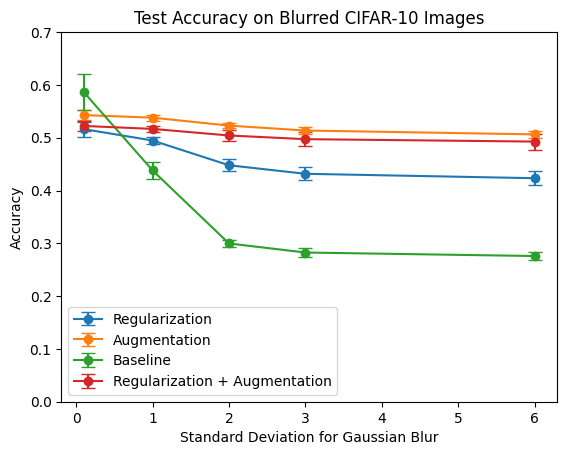

In [20]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmean, yerr=symstd, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmean, yerr=augstd, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmean, yerr=vanstd, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmean, yerr=symaugstd, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred CIFAR-10 Images')
plt.xlabel('Standard Deviation for Gaussian Blur')
plt.ylabel('Accuracy')
plt.legend()
plt.ylim(0.0,0.7)
#plt.savefig("CIFAR10_Blur.pdf")
plt.show()

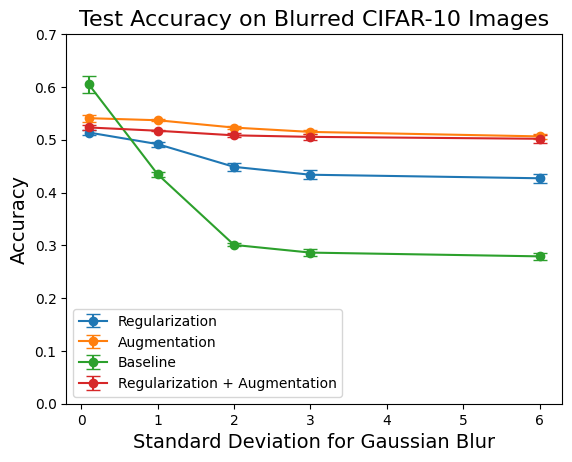

In [21]:
#plt.plot(x='x', y='y', yerr='y_error', kind='line', marker='o', capsize=4)
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symmedian, yerr=symiqr, fmt='-o', capsize=5, label="Regularization")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],augmedian, yerr=augiqr, fmt='-o', capsize=5, label="Augmentation")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],vanmedian, yerr=vaniqr, fmt='-o', capsize=5, label="Baseline")
plt.errorbar([0.1,1.0,2.0,3.0,6.0],symaugmedian, yerr=symaugiqr, fmt='-o', capsize=5, label="Regularization + Augmentation")
plt.title('Test Accuracy on Blurred CIFAR-10 Images', fontsize=16)
plt.xlabel('Standard Deviation for Gaussian Blur', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.ylim(0.0,0.7)
#plt.savefig("CIFAR10_Blur-2.pdf")
plt.show()

In [22]:
augmean

0    0.54282
1    0.53802
2    0.52292
3    0.51362
4    0.50632
dtype: float64

In [23]:
augstd

0    0.008981
1    0.005663
2    0.005238
3    0.005885
4    0.006519
dtype: float64

In [24]:
symmean

0    0.51626
1    0.49470
2    0.44782
3    0.43168
4    0.42332
dtype: float64

In [25]:
symstd

0    0.014178
1    0.006846
2    0.011321
3    0.012515
4    0.012722
dtype: float64

In [26]:
vanmean

0    0.58624
1    0.43796
2    0.29970
3    0.28258
4    0.27594
dtype: float64

In [27]:
vanstd

0    0.034194
1    0.016362
2    0.006351
3    0.007863
4    0.007854
dtype: float64

In [28]:
augmedian

0    0.5408
1    0.5369
2    0.5230
3    0.5148
4    0.5063
dtype: float64

In [29]:
augiqr

0    0.00695
1    0.00180
2    0.00345
3    0.00430
4    0.00495
dtype: float64

In [30]:
symmedian

0    0.5136
1    0.4917
2    0.4486
3    0.4337
4    0.4270
dtype: float64

In [31]:
symiqr

0    0.00480
1    0.00475
2    0.00760
3    0.00880
4    0.00855
dtype: float64

In [32]:
vanmedian

0    0.6047
1    0.4346
2    0.3008
3    0.2862
4    0.2791
dtype: float64

In [33]:
vaniqr

0    0.01610
1    0.00505
2    0.00290
3    0.00590
4    0.00600
dtype: float64

In [34]:
symaugmedian

0    0.5232
1    0.5170
2    0.5083
3    0.5054
4    0.5018
dtype: float64

In [35]:
symaugiqr

0    0.00525
1    0.00105
2    0.00405
3    0.00600
4    0.00740
dtype: float64